**3. The files hours.txt and realgdp.txt respectively contain quarterly data on average weekly hours worked and real GDP from 1964:2 to 2007:3. Compute the logarithmic growth rate of hours and of productivity (obtained as the GDP/Hours ratio).**

In [ ]:
import pandas as pd
from striprtf.striprtf import rtf_to_text

def process_rtf_to_df(file_path: str) -> pd.DataFrame:
    with open(file_path, 'r', encoding='utf-8') as f:
        raw_rtf = f.read()
        
    text = rtf_to_text(raw_rtf)
    values = [float(x.strip()) for x in text.splitlines() if x.strip()]
    
    return pd.DataFrame(values, columns=['Value'])


In [3]:
import pandas as pd
import numpy as np

raw_hours = process_rtf_to_df('data/hours.rtf')
raw_real_gdp = process_rtf_to_df('data/realgdp.rtf')

# Import hours.rtf and realgdp.rtf as a column of values. These represent quarterly data from 1964:Q2 to 2007:Q3.
# Merge the two raw dataframes
df = pd.concat([raw_hours, raw_real_gdp], axis=1)
df.columns = ['Hours', 'Real GDP']
date_range = pd.date_range(start='1964-03-30', end='2007-09-30', freq='QE')
date_q = date_range.to_period('Q')
df.insert(0, 'Quarter', date_q)

df['Prod'] = df['Real GDP'] / df['Hours']
df['ln g_h'] = df['Hours'].pct_change().apply(lambda x: np.log(1 + x))
df['ln g_A'] = df['Prod'].pct_change().apply(lambda x: np.log(1 + x))

df.head()

,Quarter,Hours,Real GDP,Prod,ln g_h,ln g_A
0,1964Q1,51.4,2984.8,58.070039,NaN,NaN
1,1964Q2,52.0,3025.5,58.182692,0.011606,0.001938
2,1964Q3,52.5,3033.6,57.782857,0.009569,-0.006896
3,1964Q4,53.0,3108.2,58.645283,0.009479,0.014815
4,1965Q1,53.8,3150.2,58.553903,0.014982,-0.001559


**(a) Estimate a VAR(1) model for the productivity growth and the hours growth. Which model is selected by BIC? Which by AIC?¹ In each case, test whether the residuals of the model(s) selected by each information criterion are serially correlated.**

In [4]:

from statsmodels.tsa.ar_model import ar_select_order

bic_gh = ar_select_order(df['ln g_h'].dropna(), maxlag=10, ic='bic')
bic_ga = ar_select_order(df['ln g_A'].dropna(), maxlag=10, ic='bic')
aic_gh = ar_select_order(df['ln g_h'].dropna(), maxlag=10, ic='aic')
aic_ga = ar_select_order(df['ln g_A'].dropna(), maxlag=10, ic='aic')

# Create a function parse_lag which extracts the optimal lag order from the aic and bic of each variable
def parse_lag(result: ar_select_order) -> int:
	if result.ar_lags is not None:
		return result.ar_lags[-1]
	else:
		return 0
	
df_ic = pd.DataFrame({
	'Variable': ['ln g_h', 'ln g_A'],
	'BIC Lag': [parse_lag(bic_gh), parse_lag(bic_ga)],
	'AIC Lag': [parse_lag(aic_gh), parse_lag(aic_ga)]
})
print(df_ic)

  Variable  BIC Lag  AIC Lag
0   ln g_h        1        9
1   ln g_A        0        0


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 16, Mar, 2026
Time:                     12:35:20
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -19.8289
Nobs:                     165.000    HQIC:                  -20.2538
Log likelihood:           1264.65    FPE:                1.19857e-09
AIC:                     -20.5442    Det(Omega_mle):     9.63818e-10
--------------------------------------------------------------------
Results for equation ln g_h
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const            -0.002720         0.001168           -2.330           0.020
L1.ln g_h         0.882463         0.086251           10.231           0.000
L1.ln g_A         0.565744         0.047842           11.825           0.00

Text(0.5, 1.0, 'PACF of Residuals for ln g_A')

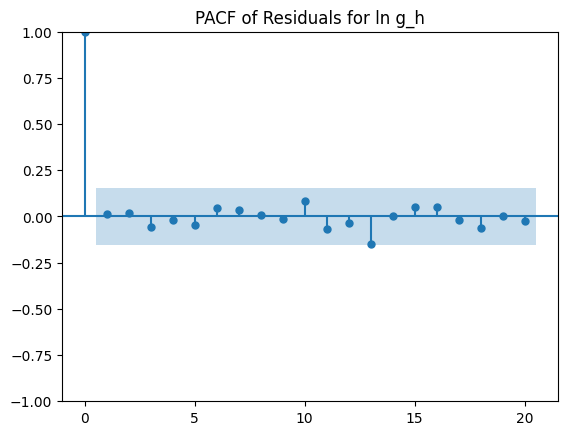

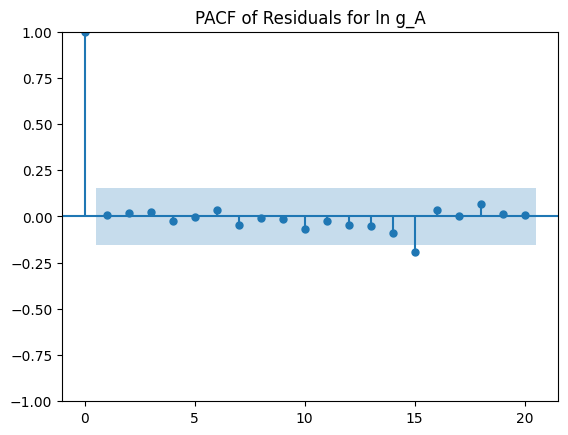

In [5]:
from statsmodels.tsa.api import VAR

lags = max(parse_lag(aic_gh), parse_lag(aic_ga))

# Filter out rows where growth was negative or zero, as log of non-positive numbers is undefined
var_data = df[['ln g_h', 'ln g_A']].replace([np.inf, -np.inf], np.nan).dropna()

model_var = VAR(var_data)
results_var = model_var.fit(lags)
summary_var = str(results_var.summary())
print(summary_var)

# Test for autocorrelation in the residuals using the Durbin-Watson test
from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(results_var.resid) - 2
print(f'Durbin-Watson statistic: {dw_stat}')

# Test for autocorrelation by plotting the PACF of the residuals
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt
plot_pacf(results_var.resid['ln g_h'].dropna(), lags=20)
plt.title('PACF of Residuals for ln g_h')

plot_pacf(results_var.resid['ln g_A'].dropna(), lags=20)
plt.title('PACF of Residuals for ln g_A')


- DW test subtracting 2 is <0.05 suggesting no autoccorelation.
- Plotting PACFs confirms this.

**(b) For the model (or models) selected in question a., compute the impulse-response functions for all variables and all shocks, up to 10 quarters, with asymptotic confidence intervals (Eviews and Stata gives you the option). What is the effect of a shock to hours growth on productivity growth? How long does it take to die out?**

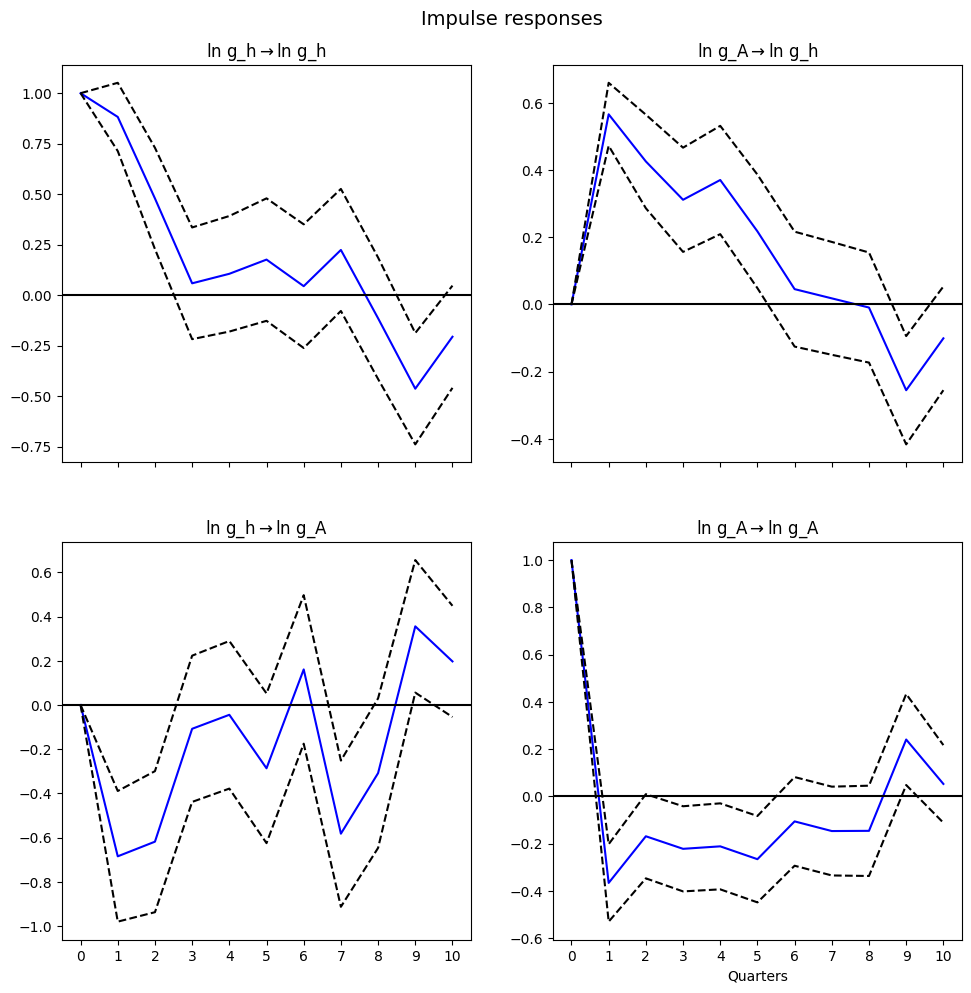

In [6]:
# Plot the IRFs
irf = results_var.irf(10)
irf.plot(orth=False)
plt.xlabel('Quarters')
plt.xticks(ticks=np.arange(0, 11, 1))
plt.show()

- Shock of hours on itself takes 4 quarters to die out. Shock of productivity on itself dies out by the next quarter, though there are 'significant' negative effects after.
- Hours negatively affects productivity in the following quarters, dying out after 3 quarters (consistent with above).
- Productivity positively affects hours in the following quarters, dying out after 6 quarters.
- The signs are consistent with economic theory.

**(c) For the model (or models) selected in question a., test whether the residuals are normally distributed. What are the implications for the use of an asymptotic confidence interval for the impulse-response function (IFR)?**

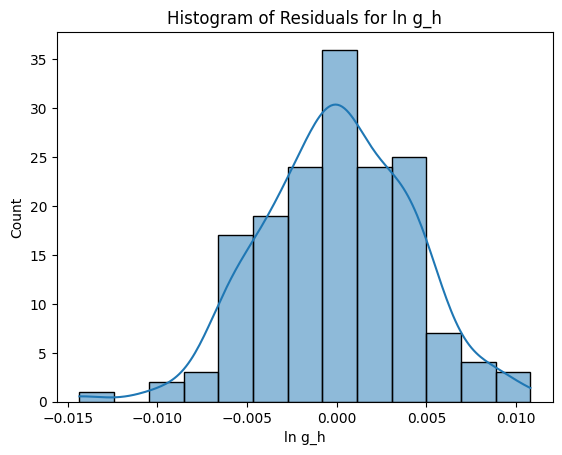

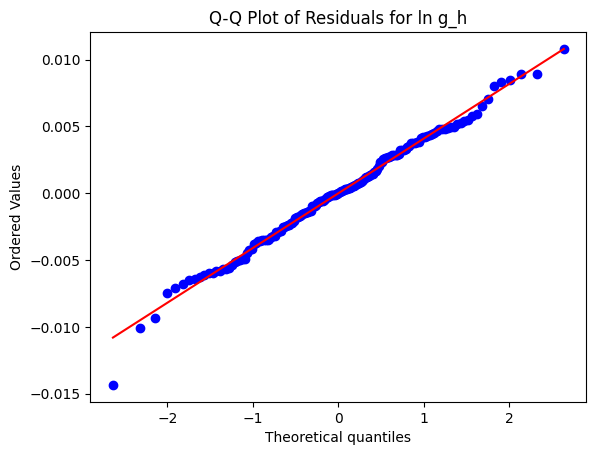

Shapiro-Wilk test statistic: 0.9930, p-value: 0.6064
Shapiro Wilk test result: Normal. Strongly insignificant p-value.


In [10]:
# Test whether residuals are normally distributed by plotting a histogram and a Q-Q plot
import seaborn as sns
sns.histplot(results_var.resid['ln g_h'].dropna(), kde=True)
plt.title('Histogram of Residuals for ln g_h')
plt.show()

import scipy.stats as stats
stats.probplot(results_var.resid['ln g_h'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals for ln g_h')
plt.show()

# Formal test for normality using the Shapiro-Wilk test
from scipy.stats import shapiro
stat, p_value = shapiro(results_var.resid['ln g_h'].dropna())
print(f'Shapiro-Wilk test statistic: {stat:.4f}, p-value: {p_value:.4f}')
print(f'Shapiro Wilk test result: {"Not normal" if p_value < 0.05 else "Normal. Strongly insignificant p-value."}')

**(d) For the model (or models) selected in question a., compute confidence intervals for the IRF that are based on re sling methods (in Eviews, you can do this by selecting the "Monte Carlo" standard errors option). Do your results change?**

In [29]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

def bootstrap_var_irf(my_df: pd.DataFrame, my_results_var: VAR, lags: int, iterations: int = 10000, steps: int = 10) -> tuple[np.ndarray, np.ndarray]:
    
    y = my_df.values
    T, K = y.shape
    coefs = my_results_var.coefs
    intercept = my_results_var.params.iloc[0].values if my_results_var.k_trend > 0 else np.zeros(K)
    resid = my_results_var.resid.values
    
    # Pre-allocate array for efficiency
    irf_store = np.zeros((iterations, steps + 1, K, K))
    
    for i in range(iterations):
        # Resampling
        idx = np.random.randint(0, len(resid), size=T)
        boot_resid = resid[idx]
        
        # Simulation
        y_boot = np.zeros((T, K))
        y_boot[:lags] = y[:lags] 
        
        for t in range(lags, T):
            y_boot[t] = intercept + boot_resid[t - lags]
            for p in range(lags):
                y_boot[t] += coefs[p] @ y_boot[t - p - 1]
                
        # Re-estimation
        boot_model = VAR(y_boot)
        boot_results = boot_model.fit(maxlags=lags)
        
        # Extract orthogonalised IRFs
        irf_store[i] = boot_results.irf(steps).orth_irfs
        
    # Aggregation
    lower_ci = np.percentile(irf_store, 2.5, axis=0)
    upper_ci = np.percentile(irf_store, 97.5, axis=0)
    
    return lower_ci, upper_ci

# Execution:
lower_bound, upper_bound = bootstrap_var_irf(var_data, results_var, lags=9, iterations=1000)


- Interpreting the above function: I previously had a VAR with g_h -> g_h, g_h -> g_A, g_A -> g_h, g_A -> g_A.
- By running the above boostrap, I will now have 1000 simulated IRFs for each of these relationships.
- I can use the distribution of these simulated IRFs to construct 95% confidence intervals for the true IRF of each relationship.
- The lower_bound and upper_bound arrays will contain the lower and upper bounds of these confidence intervals at each time step for each relationship.
- I access the confidence intervals for the g_h -> g_h relationship at time step 5 using lower_bound[5, 0, 0] and upper_bound[5, 0, 0], for example.
- I access the confidence intervals for the g_h -> g_A relationship at time step 5 using lower_bound[5, 0, 1] and upper_bound[5, 0, 1], for example.

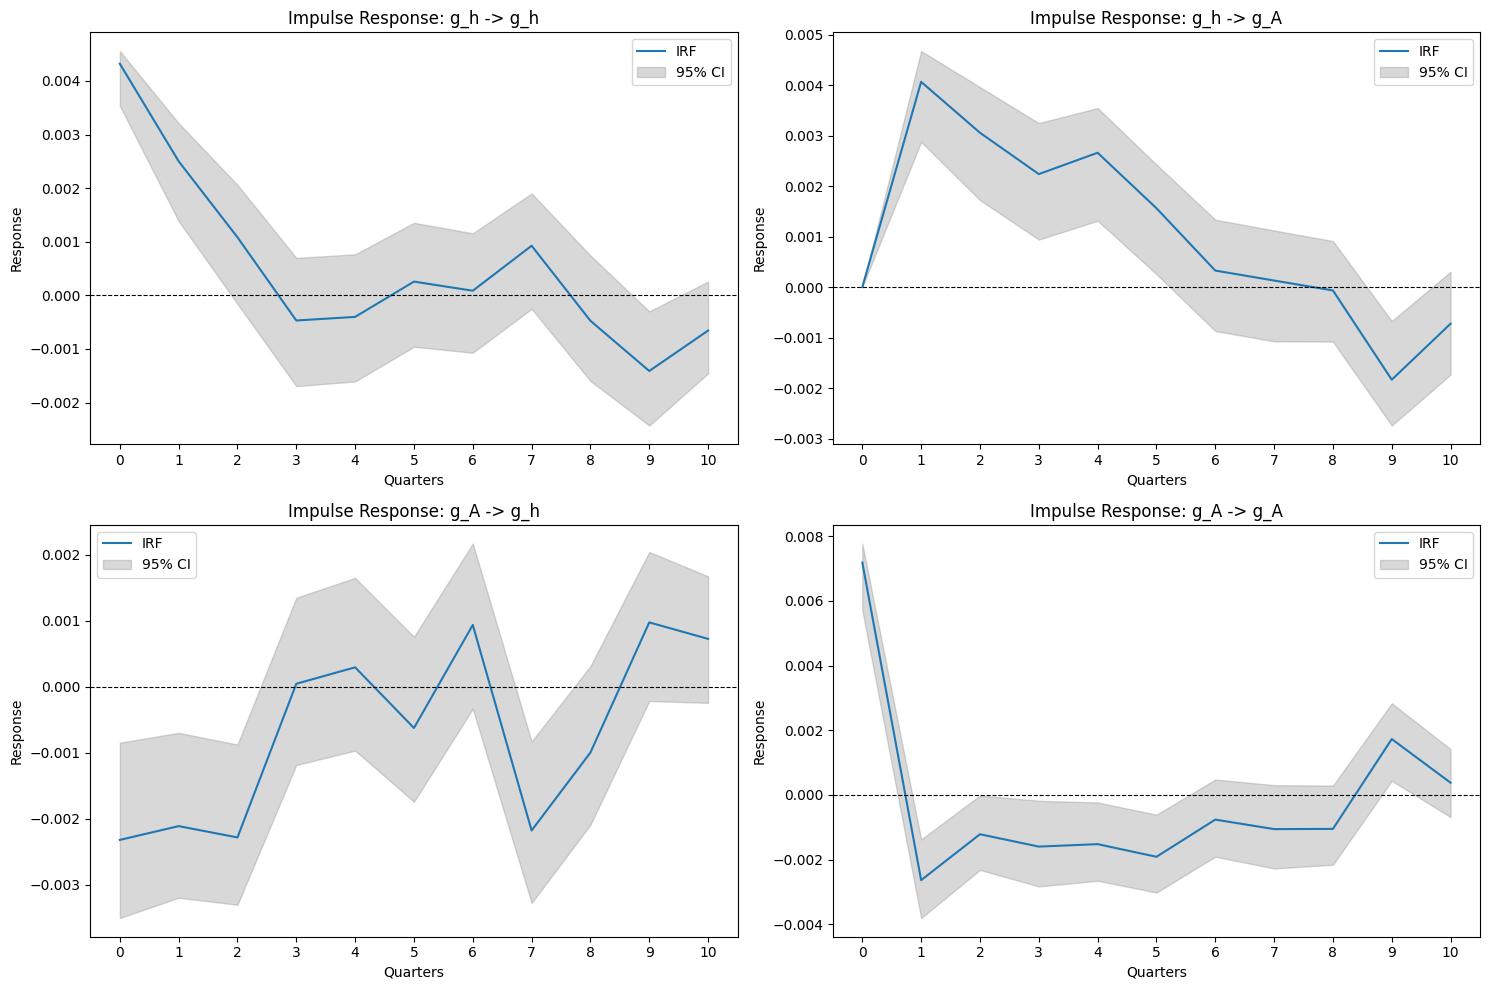

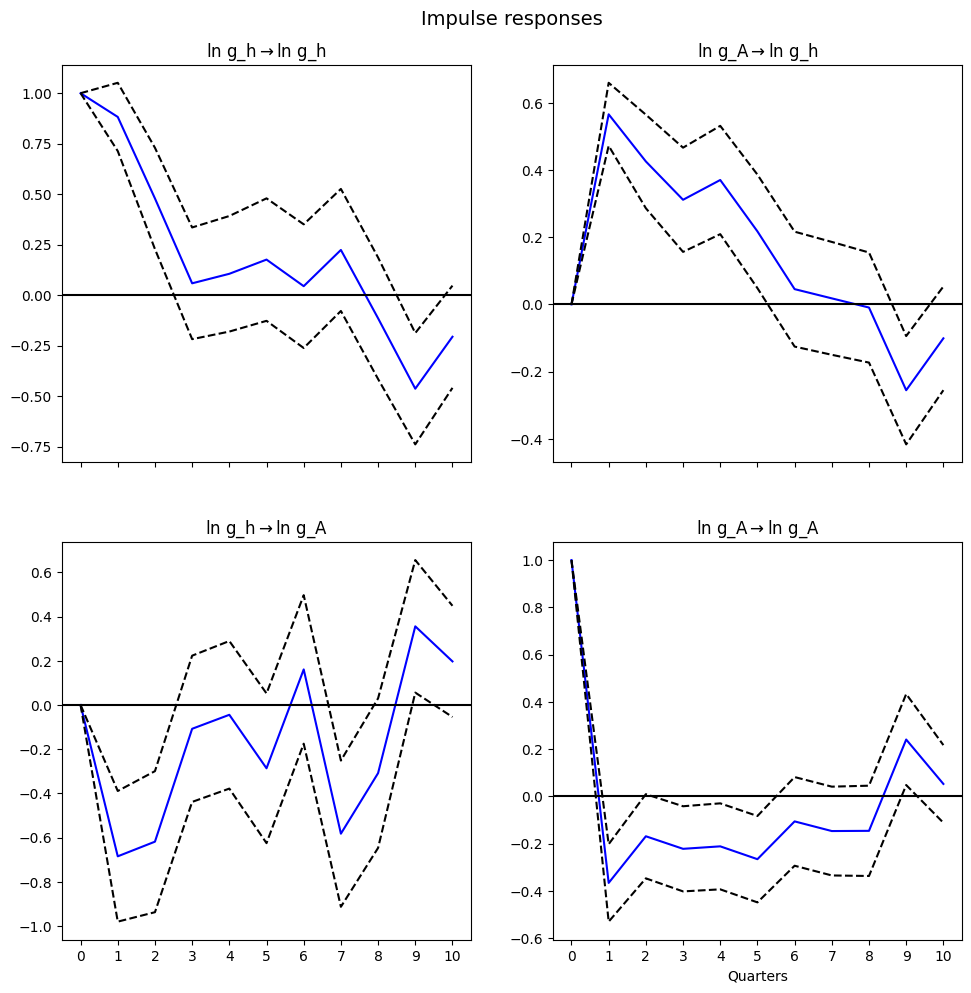

In [36]:
# Plot the IRFs with 95% confidence intervals based on the bootstrap
boostrapped_irf = pd.DataFrame({
	'Quarter': np.arange(0, 11),
	'g_h -> g_h': results_var.irf(10).orth_irfs[:, 0, 0],
	'g_h -> g_A': results_var.irf(10).orth_irfs[:, 0, 1],
	'g_A -> g_h': results_var.irf(10).orth_irfs[:, 1, 0],
	'g_A -> g_A': results_var.irf(10).orth_irfs[:, 1, 1],
	'Lower CI g_h -> g_h': lower_bound[:, 0, 0],
	'Upper CI g_h -> g_h': upper_bound[:, 0, 0],
	'Lower CI g_h -> g_A': lower_bound[:, 0, 1],
	'Upper CI g_h -> g_A': upper_bound[:, 0, 1],
	'Lower CI g_A -> g_h': lower_bound[:, 1, 0],
	'Upper CI g_A -> g_h': upper_bound[:, 1, 0],
	'Lower CI g_A -> g_A': lower_bound[:, 1, 1],
	'Upper CI g_A -> g_A': upper_bound[:, 1, 1]
})
# Plot on 4 separate subplots in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, (col, ax) in enumerate(zip(['g_h -> g_h', 'g_h -> g_A', 'g_A -> g_h', 'g_A -> g_A'], axes.flatten())):
	ax.plot(boostrapped_irf['Quarter'], boostrapped_irf[col], label='IRF')
	ax.fill_between(boostrapped_irf['Quarter'], boostrapped_irf[f'Lower CI {col}'], boostrapped_irf[f'Upper CI {col}'], color='gray', alpha=0.3, label='95% CI')
	ax.set_title(f'Impulse Response: {col}')
	ax.set_xlabel('Quarters')
	ax.set_ylabel('Response')
	ax.legend()
	ax.set_xticks(np.arange(0, 11, 1))
	ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

# Results IRF for comparison
irf = results_var.irf(10)
irf.plot(orth=False)
plt.xlabel('Quarters')
plt.xticks(ticks=np.arange(0, 11, 1))
plt.show()

- Results are **similar** which is encouraging. Cross-shock effects (ln g_h on ln g_A and vice versa) are almost identical.
- To test reasonability of shocks, labour supply shock dies out quicker. Productivity results are similar. These results are immaterial.

---
**4. Download the series x1.txt, x2.txt, x3.txt.**

In [12]:
import pandas as pd
import numpy as np

# Create a df from imported data with loop
df2 = pd.DataFrame()
for i in range(1, 4):
	raw_x = process_rtf_to_df(f'data/x{i}.rtf')
	df2 = pd.concat([df2, raw_x], axis=1)
	
df2.columns = ['x1', 'x2', 'x3']
df2.head()

,x1,x2,x3
0,-0.4326,0.9901,-1.4440
1,0.2834,2.5888,3.3962
2,-0.4602,2.7649,5.5975
3,-1.0134,3.0632,3.8865
4,-1.2031,2.7615,5.2769


**(a) Test for a unit root in the three time series**

In [21]:
# Test for a unit root in the three series using the ADF test
from statsmodels.tsa.stattools import adfuller

def difference_unit_root(series: pd.Series, max_diff_level: int = 5) -> pd.Series:
	rejects = [0] * len(series.columns)
	diff_level = 0
	while sum(rejects) < 3 and diff_level <= max_diff_level:
		print(f'\nADF test results for differencing level {diff_level}:')
		for col in series.columns:
			result = adfuller(series[col].dropna())
			print(f'ADF Statistic for {col}: {result[0]:.3f}; p-value for {col}: {result[1]:.3f}')
			if result[1] < 0.05:
				rejects[series.columns.get_loc(col)] = 1
		if sum(rejects) == 3:
			print('All series are stationary.')
			break
		diff_level += 1
		series = series.diff().dropna()
	print(f'\nFinal differencing level: {diff_level}')
	return series

df2_diff = difference_unit_root(df2)
df2_diff.head()


ADF test results for differencing level 0:
ADF Statistic for x1: -1.057; p-value for x1: 0.732
ADF Statistic for x2: -1.214; p-value for x2: 0.668
ADF Statistic for x3: -0.856; p-value for x3: 0.802

ADF test results for differencing level 1:
ADF Statistic for x1: -16.199; p-value for x1: 0.000
ADF Statistic for x2: -3.061; p-value for x2: 0.030
ADF Statistic for x3: -3.167; p-value for x3: 0.022
All series are stationary.

Final differencing level: 1


,x1,x2,x3
1,0.7160,1.5987,4.8402
2,-0.7436,0.1761,2.2013
3,-0.5532,0.2983,-1.7110
4,-0.1897,-0.3017,1.3904
5,-0.5333,-0.9011,-4.1850


**(b) Regress x1 on x2 and report the $R^{2}$ and significance of the regression coefficient. What do you conclude?**

In [36]:
# Linear regression of x1 on x2
import statsmodels.api as sm
X = df2[['x2']]
Y = df2['x1']
X_const = sm.add_constant(X)
ols_model_sm = sm.OLS(Y, X_const).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(ols_model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                     x1   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     10.43
Date:                Mon, 16 Mar 2026   Prob (F-statistic):            0.00141
Time:                        12:07:23   Log-Likelihood:                -885.79
No. Observations:                 250   AIC:                             1776.
Df Residuals:                     248   BIC:                             1783.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.6432      1.360      8.561      0.0

**(c) Plot the autocorrelogram of the residuals from the regression in point b. and do a unit root test on the residuals. What do you conclude?**

ADF Statistic for residuals: -1.464; p-value for residuals: 0.551


Text(0.5, 1.0, 'PACF of OLS Residuals')

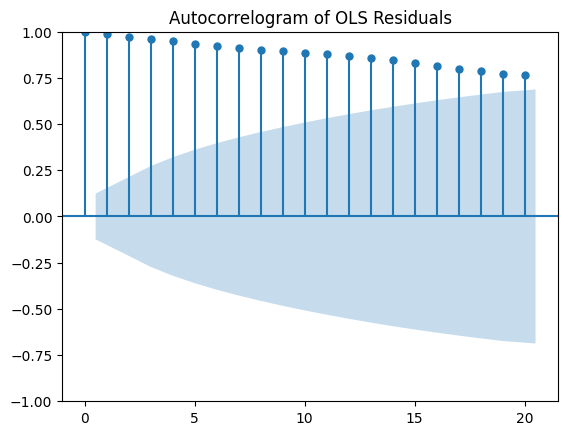

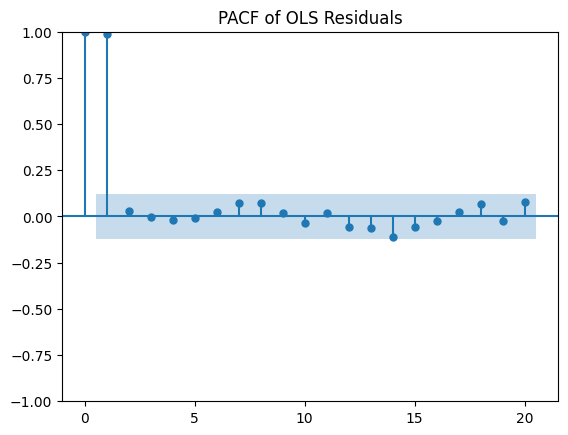

In [33]:
# Plot autocorrelogram of the residuals
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
residuals = ols_model_sm.resid
fig = plot_acf(residuals, lags=20)
fig.axes[0].set_title('Autocorrelogram of OLS Residuals')

# Unit root test on residuals
result_resid = adfuller(residuals.dropna())
print(f'ADF Statistic for residuals: {result_resid[0]:.3f}; p-value for residuals: {result_resid[1]:.3f}')

# Plot PACF of the residuals
fig2 = plot_pacf(residuals, lags=20)
fig2.axes[0].set_title('PACF of OLS Residuals')

**(d) Take first differences of x1 and x2 and repeat the analysis in point b. and c. for the first differences**

In [37]:
# Linear regression of x1 on x2
import statsmodels.api as sm
X_diff = df2_diff[['x2']]
Y_diff = df2_diff['x1']
X_const_diff = sm.add_constant(X_diff)
ols_model_sm_diff = sm.OLS(Y_diff, X_const_diff).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(ols_model_sm_diff.summary())


                            OLS Regression Results                            
Dep. Variable:                     x1   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.1195
Date:                Mon, 16 Mar 2026   Prob (F-statistic):              0.730
Time:                        12:08:15   Log-Likelihood:                -371.07
No. Observations:                 249   AIC:                             746.1
Df Residuals:                     247   BIC:                             753.2
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0813      0.065      1.257      0.2

ADF Statistic for residuals: -16.230; p-value for residuals: 0.000


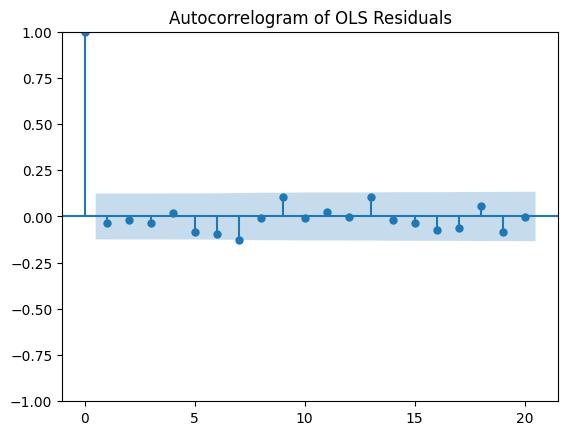

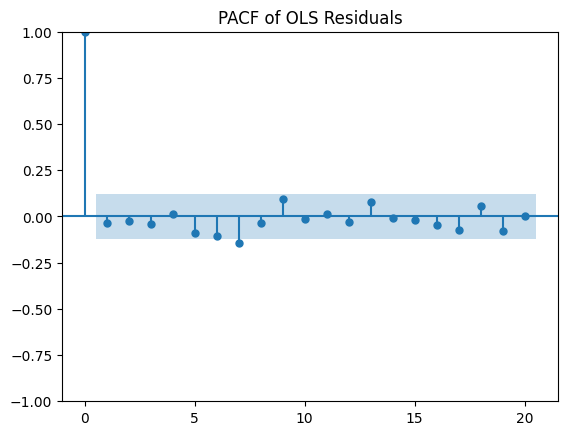

In [38]:
# Plot autocorrelogram of the residuals
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
residuals_diff = ols_model_sm_diff.resid
fig_diff = plot_acf(residuals_diff, lags=20)
fig_diff.axes[0].set_title('Autocorrelogram of OLS Residuals')

fig2_diff = plot_pacf(residuals_diff, lags=20)
fig2_diff.axes[0].set_title('PACF of OLS Residuals')

# Unit root test on residuals
r_resid_diff = adfuller(residuals_diff.dropna())
print(f'ADF Statistic for residuals: {r_resid_diff[0]:.3f}; p-value for residuals: {r_resid_diff[1]:.3f}')

No autocorrelation for errors -> good!

**(e) Test whether x1 and x2 are cointegrated with Engle-Granger**

**(f) Test whether x1, x2 and x3 are cointegrated find the number of cointegrating relationships and the cointegrating vectors with Johansen**

In [48]:
# Create a vector of every possible combination of x1, x2, and x3
from itertools import combinations

variables = ['x1', 'x2', 'x3']
combinations_list = []
for r in range(2, len(variables) + 1):
	combinations_list.extend(combinations(variables, r))
print(combinations_list)

# For every combination, test for cointegration
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, JohansenTestResult

johansen_res: JohansenTestResult = None
for combo in combinations_list:
	print(f'\nTesting cointegration for combination: {combo}')
	data = df2[list(combo)].dropna()

	if len(combo) == 2:
		# Engle-Granger requires two 1D series
		result_coint = coint(data.iloc[:, 0], data.iloc[:, 1])
		print(f'Engle-Granger test statistic: {result_coint[0]:.3f}; p-value: {result_coint[1]:.3f}')
	else:
		# For 3+ variables, use Johansen test
		johansen_res = coint_johansen(data, det_order=0, k_ar_diff=1)
		print('Johansen trace statistics:', johansen_res.lr1)
		print('Johansen 5% critical values:', johansen_res.cvt[:, 1])

[('x1', 'x2'), ('x1', 'x3'), ('x2', 'x3'), ('x1', 'x2', 'x3')]

Testing cointegration for combination: ('x1', 'x2')
Engle-Granger test statistic: -1.466; p-value: 0.774

Testing cointegration for combination: ('x1', 'x3')
Engle-Granger test statistic: -1.570; p-value: 0.733

Testing cointegration for combination: ('x2', 'x3')
Engle-Granger test statistic: -1.841; p-value: 0.609

Testing cointegration for combination: ('x1', 'x2', 'x3')
Johansen trace statistics: [108.57290835  12.05466352   2.01521678]
Johansen 5% critical values: [29.7961 15.4943  3.8415]


Johansen test suggests all 3 variables are cointegrated.
However, no combination of 2 variables is cointegrated, so we cannot use Engle-Granger. We will proceed with Johansen.

**(g) Let $\beta=(\beta_{1},\beta_{2},\beta_{3})$ be the cointegrating vector estimated in point f. above (if there are more than one, just choose one). Construct a new variable as $Y_{t}=\beta_{1}x1+\beta_{2}x2+\beta_{3}x3$ and test whether it has a unit root**

In [53]:
# Estimate the cointegration vector for the combination of x1, x2, and x3 using the Johansen test
cvec = johansen_res.evec[:, 0]
print(f'The cointegrating vector is: {cvec}')

# Take sum product of cvec and [x1, x2, x3]
cointegrating_combination = df2[['x1', 'x2', 'x3']].dot(cvec)
print('First few values of y_t')
print(cointegrating_combination.head())

# Test for unit root
result_cointegrating = adfuller(cointegrating_combination.dropna())
print(f'ADF Statistic for cointegrating combination: {result_cointegrating[0]:.3f}; p-value: {result_cointegrating[1]:.3f}')

The cointegrating vector is: [ 1.39412532  2.76441871 -1.38410302]
First few values of y_t
0    4.132597
1    2.850932
2   -0.745752
3    1.675844
4   -1.347103
dtype: float64
ADF Statistic for cointegrating combination: -15.115; p-value: 0.000


ADF has p-value < 0.05, so we reject the null of a unit root in the cointegrating combination.